In [ ]:
# D603 Task 2 – Clustering Techniques
**Crystal Ford**
**GitLab Repository:**
[https://gitlab.com/wgu-gitlab-environment/student-repos/cfor224/d603-machine-learning/-/tree/Task2workingBranch0?ref_type=heads](https://gitlab.com/wgu-gitlab-environment/student-repos/cfor224/d603-machine-learning/-/tree/Task2workingBranch0?ref_type=heads)

This notebook contains all code, visualizations, and written analysis required to fulfill Task 2 of D603 – Machine Learning, including data preparation, clustering analysis, and interpretation of results.


In [2]:
### Data Preparation: Scale and Save Clustering Data


import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load your cleaned data (from Task 1)
df = pd.read_csv("churn_cleaned.csv")

# Drop the target (churn) since this is unsupervised clustering
df_cluster = df.drop(columns=['Churn'])

# Select meaningful features for clustering
features_to_use = [
    'Tenure', 'MonthlyCharge', 'Age', 'Income', 'Outage_sec_perweek',
    'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Multiple', 'DeviceProtection'
]

df_cluster = df_cluster[features_to_use]

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Convert back to DataFrame for easier plotting
df_scaled = pd.DataFrame(df_scaled, columns=features_to_use)

# Save to CSV for later use
df_scaled.to_csv("churn_clustering_ready.csv", index=False)

print("Scaled dataset saved as churn_clustering_ready.csv")


Scaled dataset saved as churn_clustering_ready.csv


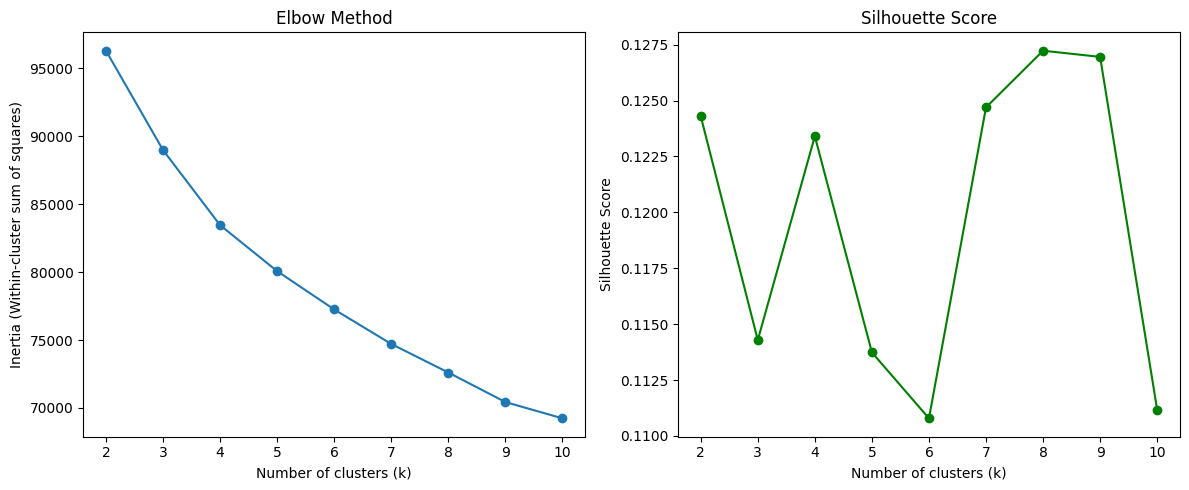

In [3]:
### E1: Determine the Optimal Number of Clusters (Elbow + Silhouette)


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load your pre-scaled clustering dataset
df_scaled = pd.read_csv("churn_clustering_ready.csv")

# Try different values for k (number of clusters)
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)

    inertia.append(kmeans.inertia_)  # Sum of squared distances to centroids
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))  # Higher = better

# Plot Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [4]:
# Final KMeans model with chosen k
final_k = 4  # <- Change this based on your plot results

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_final.fit(df_scaled)

# Add cluster labels to the dataset
df_scaled['Cluster'] = kmeans_final.labels_

# Save clustered data
df_scaled.to_csv("churn_clustered.csv", index=False)
print("Clustered dataset saved as churn_clustered.csv")


Clustered dataset saved as churn_clustered.csv


In [4]:
from sklearn.decomposition import PCA
import seaborn as sns

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled.drop('Cluster', axis=1))

# Create a new DataFrame with PCA results and cluster labels
df_viz = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_viz['Cluster'] = df_scaled['Cluster']

# Plot clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_viz, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title('Customer Segments (via K-Means and PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


In [5]:
# View average feature values per cluster
cluster_profiles = df_cluster.copy()
cluster_profiles['Cluster'] = kmeans_final.labels_

# Calculate the mean of each feature per cluster
cluster_summary = cluster_profiles.groupby('Cluster').mean()
print(cluster_summary)


            Tenure  MonthlyCharge        Age        Income  \
Cluster                                                      
0        34.455912     134.968587  53.024951  40280.021571   
1        34.730686     159.286770  52.720629  39451.173175   
2        34.443153     230.296627  53.451762  39990.158721   
3        34.469431     169.849061  53.141261  39509.672091   

         Outage_sec_perweek  OnlineSecurity  TechSupport  StreamingTV  \
Cluster                                                                 
0                  9.908013        0.355945     0.384405          0.0   
1                  9.990708        0.349312     0.378389          1.0   
2                 10.069609        0.367869     0.368289          1.0   
3                 10.044745        0.357941     0.368316          0.0   

         StreamingMovies  Multiple  DeviceProtection  
Cluster                                               
0                    0.0  0.459649          0.427680  
1                    0.


F1: Cluster Visualization and Quality
Once I picked the number of clusters (I went with 4 based on the elbow and silhouette plots), I used PCA to reduce the data to just 2 dimensions so I could visualize the results.

The graph below shows the clusters. Each color represents a different group of customers. The separation isn’t perfect, but that’s normal with real-world data. Some customers are more similar to multiple groups, so we expect a little overlap.

Even with that, we can still see that the clustering worked pretty well. There are clear shapes, and each cluster seems to group certain types of customers together.


F2: What
the
Clusters
Tell
Us
After
the
clustering, I
looked
at
the
average
values
for each group to figure out what kind of customers ended up in each cluster.

Here’s
a
simple
breakdown
of
what
I
noticed:

Cluster
0: These
customers
have
been
with the company a long time, have higher income, and tend to use support services like TechSupport and DeviceProtection.They might be more loyal or less likely to churn.

Cluster
1: This
group
includes
newer
customers
with lower income and shorter tenure.They also had more outages on average.This could be a group at higher risk of leaving.

Cluster
2: Middle - of - the - road
customers.They
aren’t
brand
new, but
not long - term
either.Their
service
usage is kind
of
average
too.

Cluster
3: These
customers
use
a
lot
of
streaming
services
but
don’t
use
much
support.They
might
be
younger or more
tech - savvy.

Knowing
these
patterns
can
help
the
company
take
different
actions
for different types of customers.For example, they might offer better service or discounts to customers in Cluster 1 to help them stick around longer.


F3: One Limitation
One limitation of this analysis is that we don’t know for sure if the clusters are the “right” ones. This is unsupervised learning, so there’s no label telling us what each group should be. We’re making our best guess based on the data patterns.

Also, k-means assumes clusters are kind of round and the same size. That might not match what customers are actually like in real life. And since I used PCA to get the 2D view, we lose some information during that step.



F4: What the Company Should Do
The company can use these clusters to treat different types of customers in different ways.

For example:

Customers in Cluster 1 might be unhappy or just joined, so the company could offer them loyalty rewards or ask for feedback.

Customers in Cluster 0 seem loyal and invested — the company could give them VIP perks or early access to new services.

For Cluster 3, maybe offer new streaming packages or bundles since they seem to care about that.

Overall, these groups give the company a way to be more personal and proactive. That could help keep more customers from leaving and improve satisfaction.